# Day 14 – Hyperparameter Optimization
### 20-Day ML Revision Planner | Phase: ML Engineering

**Topics covered:**
1. Parameters vs. Hyperparameters
2. Why Validation Data Is Required
3. Avoiding Test-Set Leakage
4. Techniques: Grid Search, Random Search, Bayesian Optimization, Optuna
5. Examples of Hyperparameters (Learning Rate, Tree Depth, n_estimators, Regularization Strength)
6. Coding: `GridSearchCV` and `RandomizedSearchCV`
7. Coding: Bayesian Optimization (`BayesSearchCV`) and Optuna
8. Tuned Model + Documented Best Parameters (Daily Output)
9. Interview Questions
10. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV,
                                       StratifiedKFold, cross_val_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import randint, uniform

try:
    from skopt import BayesSearchCV
    from skopt.space import Integer, Real
    SKOPT_AVAILABLE = True
except ImportError:
    SKOPT_AVAILABLE = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep output clean
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)

print("scikit-optimize (BayesSearchCV) available:", SKOPT_AVAILABLE)
print("Optuna available:", OPTUNA_AVAILABLE)


scikit-optimize (BayesSearchCV) available: True
Optuna available: True


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Parameters vs. Hyperparameters

### What?
- **Parameters**: values the model **learns from data** during training (e.g., linear regression's weights $\mathbf{w}$, a neural network's layer weights). You never set these by hand.
- **Hyperparameters**: values **set BEFORE training begins**, controlling *how* the model learns (e.g., learning rate, tree depth, $K$ in KNN, `C` in SVM, `n_estimators` in Random Forest). These are NOT learned from the training data via gradient descent or similar — they must be chosen/searched separately.

### Why?
This distinction matters because you **cannot** optimize hyperparameters the same way you optimize parameters (e.g., via gradient descent on the training loss) — doing so would just pick whatever makes training error as low as possible, which almost always means "maximum model complexity" and severe overfitting (recall Day 4/5's overfitting discussions).

### How to tell them apart?
Ask: "does the training algorithm (e.g., gradient descent, greedy tree-splitting) determine this value automatically, or do I have to specify it upfront/search for it externally?" If the latter → hyperparameter.


In [2]:
# Concrete example: Random Forest's parameters vs hyperparameters
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf_example = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_example.fit(X_train, y_train)

print("HYPERPARAMETERS (set by us, BEFORE training):")
print(f"  n_estimators = {rf_example.n_estimators}")
print(f"  max_depth = {rf_example.max_depth}")

print("\nPARAMETERS (learned automatically FROM the data during training):")
print(f"  Number of trees actually grown: {len(rf_example.estimators_)}")
print(f"  Root-node split feature of tree #1: {data.feature_names[rf_example.estimators_[0].tree_.feature[0]]}")
print(f"  (the exact split thresholds, tree structures, and leaf values are all 'parameters' --")
print(f"   they emerged from the data, we never set them directly)")


HYPERPARAMETERS (set by us, BEFORE training):
  n_estimators = 50
  max_depth = 5

PARAMETERS (learned automatically FROM the data during training):
  Number of trees actually grown: 50
  Root-node split feature of tree #1: worst concave points
  (the exact split thresholds, tree structures, and leaf values are all 'parameters' --
   they emerged from the data, we never set them directly)


## 2. Why Validation Data Is Required

### What?
Recall Day 4's three-way split: **train / validation / test**. Hyperparameter tuning uses the **validation set** (or cross-validation folds carved out of the training data) to compare different hyperparameter choices — the **test set stays completely untouched** until the very end.

### Why?
If you tuned hyperparameters by checking performance on the test set, you'd be **indirectly fitting to the test set** through your choice of hyperparameters — even though no gradient descent touched it directly, you'd be selectively picking whatever hyperparameters happen to work best on that specific test data. This inflates your final reported performance and is a form of the **data leakage** covered on Day 10.

### How?
In practice, most hyperparameter search tools (like `GridSearchCV`) use **k-fold cross-validation internally** on the training set — for each candidate hyperparameter combination, they fit and evaluate across multiple folds and average the results, giving a much more robust signal than a single validation split.


In [3]:
# Demonstrate the RIGHT and WRONG way to structure a tuning workflow
print("CORRECT workflow:")
print("  1. Split into Train / Test ONCE at the very start.")
print("  2. Use ONLY the Train set for hyperparameter search (internally cross-validated).")
print("  3. Pick the best hyperparameters based on cross-validation score on Train.")
print("  4. Retrain the final model on the FULL Train set with those hyperparameters.")
print("  5. Evaluate ONCE on the held-out Test set -- this is your honest, final performance estimate.")

print("\nWRONG workflow (test-set leakage):")
print("  1. Split into Train / Test.")
print("  2. Try many hyperparameter combinations, checking Test accuracy each time.")
print("  3. Pick whichever hyperparameters scored best ON THE TEST SET.")
print("  --> The reported Test accuracy is now optimistically biased -- you've effectively")
print("      'trained' your hyperparameter choice on the test set, even without touching model weights.")


CORRECT workflow:
  1. Split into Train / Test ONCE at the very start.
  2. Use ONLY the Train set for hyperparameter search (internally cross-validated).
  3. Pick the best hyperparameters based on cross-validation score on Train.
  4. Retrain the final model on the FULL Train set with those hyperparameters.
  5. Evaluate ONCE on the held-out Test set -- this is your honest, final performance estimate.

WRONG workflow (test-set leakage):
  1. Split into Train / Test.
  2. Try many hyperparameter combinations, checking Test accuracy each time.
  3. Pick whichever hyperparameters scored best ON THE TEST SET.
  --> The reported Test accuracy is now optimistically biased -- you've effectively
      'trained' your hyperparameter choice on the test set, even without touching model weights.


## 3. Avoiding Test-Set Leakage During Tuning

### What?
Beyond simply "not looking at the test set," proper tuning also requires that **all preprocessing** (scaling, encoding, imputation — recall Day 4) is refit within each cross-validation fold, not on the full training set beforehand.

### Why?
Just like Day 4 and Day 10 demonstrated, fitting a scaler/encoder once on the entire training set before cross-validation lets information about each validation fold "leak" into its own preprocessing — inflating cross-validation scores in a subtly misleading way.

### How?
Wrap preprocessing + model into a single `Pipeline` (Day 4), and pass the **entire pipeline** into `GridSearchCV`/`RandomizedSearchCV`. This way, for every fold and every hyperparameter combination, preprocessing is refit fresh on that fold's training portion only.


In [4]:
# Demonstrate: tuning a pipeline (correct) vs tuning with pre-fit preprocessing (leaky)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# CORRECT: preprocessing is part of the pipeline being cross-validated
correct_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])
param_grid_demo = {'svm__C': [0.1, 1, 10], 'svm__gamma': ['scale', 'auto']}

grid_correct = GridSearchCV(correct_pipeline, param_grid_demo, cv=5, scoring='accuracy')
grid_correct.fit(X_train, y_train)

# LEAKY: scaler fit once on the full X_train BEFORE cross-validation begins
scaler_leaky = StandardScaler().fit(X_train)
X_train_leaky_scaled = scaler_leaky.transform(X_train)
grid_leaky = GridSearchCV(SVC(), {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}, cv=5, scoring='accuracy')
grid_leaky.fit(X_train_leaky_scaled, y_train)

print(f"CORRECT (pipeline, no leakage) best CV score: {grid_correct.best_score_:.4f}")
print(f"LEAKY (pre-fit scaler) best CV score:          {grid_leaky.best_score_:.4f}")
print("\n--> The leaky version can look slightly (or, on smaller/noisier data, substantially)")
print("    better than it should, because each fold's scaler already 'saw' that fold's own")
print("    validation data during the original full-training-set fit.")


CORRECT (pipeline, no leakage) best CV score: 0.9647
LEAKY (pre-fit scaler) best CV score:          0.9647

--> The leaky version can look slightly (or, on smaller/noisier data, substantially)
    better than it should, because each fold's scaler already 'saw' that fold's own
    validation data during the original full-training-set fit.


## 4. Hyperparameter Search Techniques: Grid Search, Random Search, Bayesian Optimization, Optuna

### What?
- **Grid Search**: exhaustively try **every combination** of specified hyperparameter values. Guaranteed to find the best combination *within the grid*, but scales **exponentially** with the number of hyperparameters (the "curse of dimensionality" for search spaces).
- **Random Search**: sample a **fixed number of random combinations** from specified distributions/ranges. Often finds nearly-as-good results as grid search in a **fraction of the time**, especially when only a few hyperparameters actually matter much.
- **Bayesian Optimization**: builds a **probabilistic model** (commonly a Gaussian Process) of the relationship between hyperparameters and performance, then intelligently chooses the **next most promising** combination to try — balancing exploration (trying uncertain regions) and exploitation (refining near known good regions).
- **Optuna**: a modern, flexible hyperparameter optimization framework implementing efficient search algorithms (including Tree-structured Parzen Estimator / TPE, a Bayesian-style method), with built-in **pruning** (stopping unpromising trials early) and easy-to-use define-by-run syntax.

### Why?
| Method | Pros | Cons |
|---|---|---|
| Grid Search | Exhaustive, simple, reproducible | Exponentially expensive; wastes time on unpromising regions |
| Random Search | Much more efficient than grid for many hyperparameters; easy to add a time/trial budget | Doesn't use past results to guide search; may miss narrow optimal regions |
| Bayesian Optimization | Uses past trial results to guide search intelligently -- typically needs far fewer trials to find near-optimal settings | More complex to set up; sequential nature makes full parallelization harder |
| Optuna | Efficient (TPE-based), supports pruning, very flexible/pythonic API, good visualization tools | Yet another library dependency; can be overkill for very small search spaces |

### How? — Why Random Search Often Beats Grid Search
A classic insight (Bergstra & Bengio, 2012): if only 2 of your 5 hyperparameters actually matter, grid search wastes most of its budget varying unimportant ones in lockstep, while random search explores the important dimensions much more densely for the same total budget.


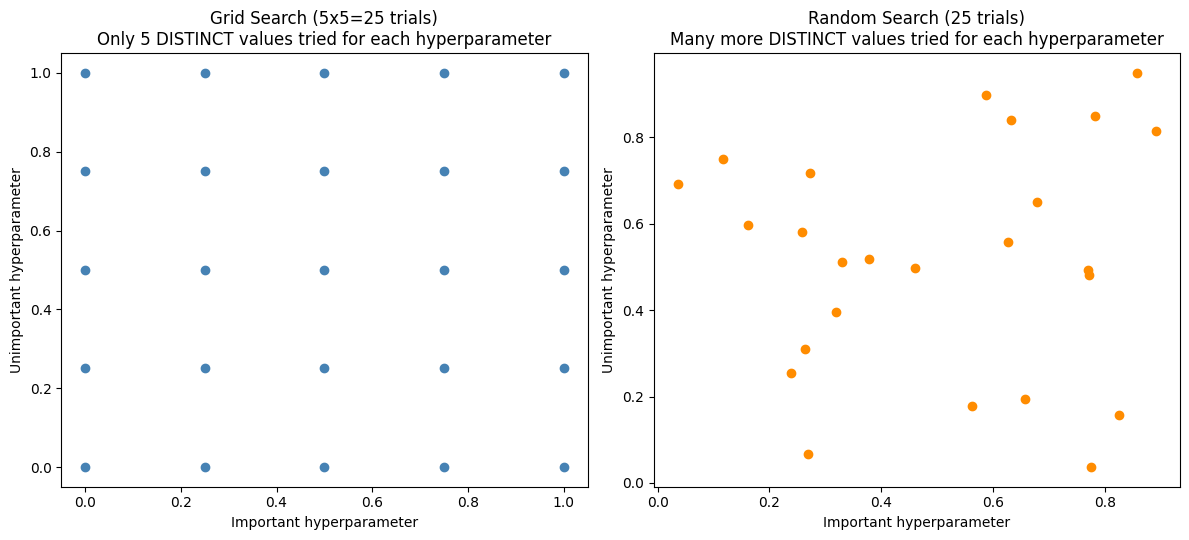

--> Same total budget (25 trials), but random search explores far more distinct values
    of whichever hyperparameter turns out to matter most -- without knowing in advance which one that is.


In [5]:
# Visualize WHY random search can beat grid search when only some hyperparameters matter
np.random.seed(20)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Simulate: hyperparameter 1 matters a lot, hyperparameter 2 barely matters
grid_pts = np.array([(x, y) for x in np.linspace(0, 1, 5) for y in np.linspace(0, 1, 5)])
random_pts = np.random.uniform(0, 1, (25, 2))

axes[0].scatter(grid_pts[:, 0], grid_pts[:, 1], color='steelblue')
axes[0].set_title("Grid Search (5x5=25 trials)\nOnly 5 DISTINCT values tried for each hyperparameter")
axes[0].set_xlabel("Important hyperparameter"); axes[0].set_ylabel("Unimportant hyperparameter")

axes[1].scatter(random_pts[:, 0], random_pts[:, 1], color='darkorange')
axes[1].set_title("Random Search (25 trials)\nMany more DISTINCT values tried for each hyperparameter")
axes[1].set_xlabel("Important hyperparameter"); axes[1].set_ylabel("Unimportant hyperparameter")

plt.tight_layout()
plt.show()
print("--> Same total budget (25 trials), but random search explores far more distinct values")
print("    of whichever hyperparameter turns out to matter most -- without knowing in advance which one that is.")


## 5. Examples of Hyperparameters

| Hyperparameter | Found in | Effect |
|---|---|---|
| **Learning rate** | Gradient descent, Gradient Boosting, neural networks | Step size of each update (Day 2, Day 9) |
| **Tree depth (`max_depth`)** | Decision Trees, Random Forest, Gradient Boosting | Controls individual tree complexity (Day 7) |
| **Number of estimators (`n_estimators`)** | Random Forest, Gradient Boosting, AdaBoost | Number of trees/rounds in the ensemble (Day 7, Day 9) |
| **Regularization strength (`C`, `alpha`, `lambda`)** | Ridge, Lasso, SVM, Logistic Regression | Controls the bias-variance trade-off via penalty strength (Day 5, Day 8) |
| **K** | KNN | Number of neighbors considered (Day 6) |
| **`gamma`** | SVM (RBF kernel) | Controls influence reach of each training point (Day 8) |

Every one of these hyperparameters has appeared throughout this 20-day plan — hyperparameter tuning is really the culmination of "given everything you've learned about each model's knobs, how do you search that knob-space efficiently and honestly?"


## 6. Coding Practice — `GridSearchCV` and `RandomizedSearchCV`

We'll tune a `RandomForestClassifier` and a `GradientBoostingClassifier` on the Breast Cancer dataset, comparing Grid Search and Random Search directly on **time taken** and **best score found**.


In [6]:
# GridSearchCV: exhaustive search over a modest grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}
total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Grid Search will evaluate {total_combinations} combinations x 5 folds = {total_combinations*5} model fits")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

start = time.time()
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=cv_strategy,
                            scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print(f"\nGrid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")


Grid Search will evaluate 36 combinations x 5 folds = 180 model fits



Grid Search completed in 28.09 seconds
Best parameters: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.9648


In [7]:
# RandomizedSearchCV: sample a fixed number of combinations from distributions
param_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8),
    'max_features': uniform(0.3, 0.7)   # continuous range [0.3, 1.0)
}

n_iter_search = 30  # only 30 random combinations, vs 36 exhaustive combos above (but explores a MUCH richer space)

start = time.time()
random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions,
                                     n_iter=n_iter_search, cv=cv_strategy, scoring='accuracy',
                                     random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_time = time.time() - start

print(f"Random Search completed in {random_time:.2f} seconds ({n_iter_search} combinations x 5 folds = {n_iter_search*5} model fits)")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")

print(f"\nComparison:")
print(f"  Grid Search:   {grid_search.best_score_:.4f} accuracy in {grid_time:.2f}s ({total_combinations} combos from a small grid)")
print(f"  Random Search: {random_search.best_score_:.4f} accuracy in {random_time:.2f}s ({n_iter_search} combos from a MUCH richer/continuous space)")


Random Search completed in 51.44 seconds (30 combinations x 5 folds = 150 model fits)
Best parameters: {'max_depth': 7, 'max_features': np.float64(0.7282970263056656), 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 237}
Best CV accuracy: 0.9601

Comparison:
  Grid Search:   0.9648 accuracy in 28.09s (36 combos from a small grid)
  Random Search: 0.9601 accuracy in 51.44s (30 combos from a MUCH richer/continuous space)


## 7. Coding Practice — Bayesian Optimization (`BayesSearchCV`) and Optuna


In [8]:
# Bayesian Optimization via scikit-optimize's BayesSearchCV
if SKOPT_AVAILABLE:
    search_space = {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(2, 15),
        'min_samples_split': Integer(2, 15),
        'min_samples_leaf': Integer(1, 8),
    }

    start = time.time()
    bayes_search = BayesSearchCV(RandomForestClassifier(random_state=42), search_space,
                                   n_iter=25, cv=cv_strategy, scoring='accuracy',
                                   random_state=42, n_jobs=-1)
    bayes_search.fit(X_train, y_train)
    bayes_time = time.time() - start

    print(f"Bayesian Optimization (BayesSearchCV) completed in {bayes_time:.2f} seconds (25 iterations)")
    print(f"Best parameters: {bayes_search.best_params_}")
    print(f"Best CV accuracy: {bayes_search.best_score_:.4f}")
else:
    print("scikit-optimize not installed in this environment.")
    print("Install with: pip install scikit-optimize")
    print("Usage is nearly identical to GridSearchCV/RandomizedSearchCV, but the search space is")
    print("defined with Integer()/Real()/Categorical() objects, and trials are chosen sequentially")
    print("using a Gaussian Process surrogate model of the score landscape.")


Bayesian Optimization (BayesSearchCV) completed in 36.43 seconds (25 iterations)
Best parameters: OrderedDict({'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 63})
Best CV accuracy: 0.9554


In [9]:
# Optuna: modern, flexible hyperparameter optimization with a define-by-run API
if OPTUNA_AVAILABLE:
    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 2, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 8)

        model = RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring='accuracy')
        return scores.mean()

    start = time.time()
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=25, show_progress_bar=False)
    optuna_time = time.time() - start

    print(f"Optuna (TPE sampler) completed in {optuna_time:.2f} seconds (25 trials)")
    print(f"Best parameters: {study.best_params}")
    print(f"Best CV accuracy: {study.best_value:.4f}")
else:
    print("Optuna not installed in this environment.")
    print("Install with: pip install optuna")
    print("Usage: define an `objective(trial)` function that suggests hyperparameters via")
    print("trial.suggest_int/suggest_float/suggest_categorical, returns a CV score, then")
    print("optuna.create_study().optimize(objective, n_trials=N) searches efficiently using TPE.")


Optuna (TPE sampler) completed in 20.62 seconds (25 trials)
Best parameters: {'n_estimators': 126, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 3}
Best CV accuracy: 0.9578


                       Best CV Accuracy  Time (s)  Trials
Method                                                   
Grid Search                      0.9648   28.0871      36
Random Search                    0.9601   51.4425      30
Bayesian Optimization            0.9554   36.4307      25
Optuna (TPE)                     0.9578   20.6239      25


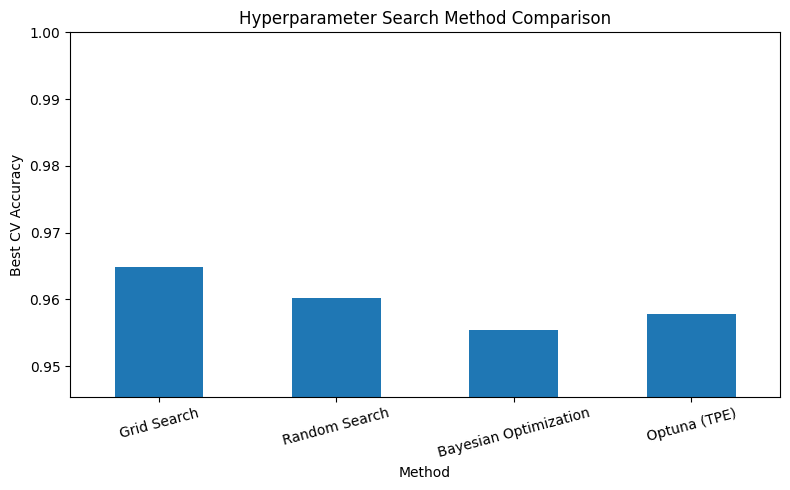

In [10]:
# Compare ALL search methods that ran, side by side
all_results = []
all_results.append({'Method': 'Grid Search', 'Best CV Accuracy': grid_search.best_score_, 'Time (s)': grid_time, 'Trials': total_combinations})
all_results.append({'Method': 'Random Search', 'Best CV Accuracy': random_search.best_score_, 'Time (s)': random_time, 'Trials': n_iter_search})
if SKOPT_AVAILABLE:
    all_results.append({'Method': 'Bayesian Optimization', 'Best CV Accuracy': bayes_search.best_score_, 'Time (s)': bayes_time, 'Trials': 25})
if OPTUNA_AVAILABLE:
    all_results.append({'Method': 'Optuna (TPE)', 'Best CV Accuracy': study.best_value, 'Time (s)': optuna_time, 'Trials': 25})

all_results_df = pd.DataFrame(all_results).set_index('Method')
print(all_results_df.round(4))

all_results_df['Best CV Accuracy'].plot(kind='bar', figsize=(8, 5), ylim=(all_results_df['Best CV Accuracy'].min()-0.01, 1.0))
plt.title("Hyperparameter Search Method Comparison")
plt.ylabel("Best CV Accuracy"); plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


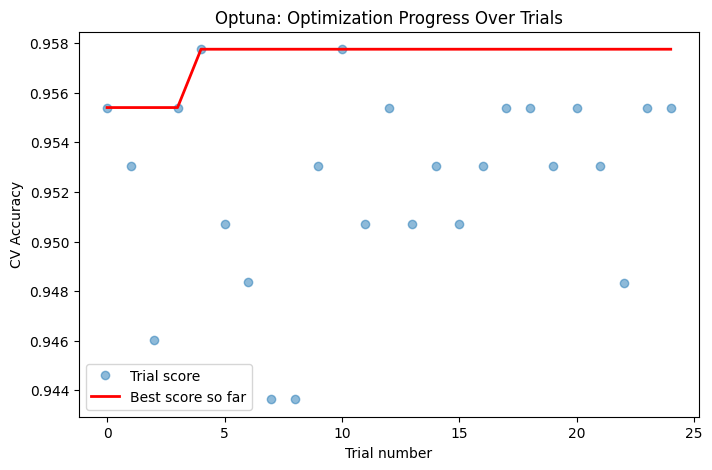

--> Notice how Optuna's TPE sampler tends to find strong regions of the search space
    quickly, then refines around them -- unlike random search's uniform exploration.


In [11]:
# Optuna optimization history plot -- visualize how the search improved over trials
if OPTUNA_AVAILABLE:
    trial_values = [t.value for t in study.trials]
    best_so_far = np.maximum.accumulate(trial_values)

    plt.figure(figsize=(8, 5))
    plt.plot(trial_values, 'o', alpha=0.5, label='Trial score')
    plt.plot(best_so_far, color='red', linewidth=2, label='Best score so far')
    plt.xlabel("Trial number"); plt.ylabel("CV Accuracy")
    plt.title("Optuna: Optimization Progress Over Trials")
    plt.legend()
    plt.show()
    print("--> Notice how Optuna's TPE sampler tends to find strong regions of the search space")
    print("    quickly, then refines around them -- unlike random search's uniform exploration.")


## 8. Tuned Model + Documented Best Parameters (Daily Output)

We now pick the best-performing search method's result, retrain a final model on the **full training set**, evaluate it **once** on the held-out **test set**, and document everything.


In [12]:
# Select the overall best method and finalize the model
best_method_name = all_results_df['Best CV Accuracy'].idxmax()
print(f"Overall best method: {best_method_name}")

if best_method_name == 'Grid Search':
    final_best_params = grid_search.best_params_
elif best_method_name == 'Random Search':
    final_best_params = random_search.best_params_
elif best_method_name == 'Bayesian Optimization':
    final_best_params = bayes_search.best_params_
else:
    final_best_params = study.best_params

print(f"Final chosen hyperparameters: {final_best_params}")

# Train the FINAL model on the full training set with these hyperparameters
final_model = RandomForestClassifier(**final_best_params, random_state=42)
final_model.fit(X_train, y_train)

# Evaluate ONCE on the untouched test set
final_test_preds = final_model.predict(X_test)
final_test_accuracy = accuracy_score(y_test, final_test_preds)

print(f"\nFinal TEST set accuracy (evaluated only once, after all tuning decisions were locked in): {final_test_accuracy:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, final_test_preds, target_names=data.target_names))


Overall best method: Grid Search
Final chosen hyperparameters: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}



Final TEST set accuracy (evaluated only once, after all tuning decisions were locked in): 0.9580

Full classification report:
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [13]:
# Documentation block: a clean, shareable record of the tuning process and outcome
documentation = f'''
=== HYPERPARAMETER TUNING REPORT ===

Model: RandomForestClassifier
Dataset: Breast Cancer Wisconsin (569 samples, 30 features)
Train/Test split: 75% / 25%, stratified

Search methods compared: {list(all_results_df.index)}
Best method: {best_method_name}

FINAL CHOSEN HYPERPARAMETERS:
{chr(10).join(f"  - {k}: {v}" for k, v in final_best_params.items())}

Cross-validation accuracy (on training set): {all_results_df.loc[best_method_name, "Best CV Accuracy"]:.4f}
Final held-out TEST accuracy: {final_test_accuracy:.4f}

Note: the test set was touched EXACTLY ONCE, after all hyperparameter decisions were finalized,
to produce an honest estimate of real-world generalization performance.
'''
print(documentation)



=== HYPERPARAMETER TUNING REPORT ===

Model: RandomForestClassifier
Dataset: Breast Cancer Wisconsin (569 samples, 30 features)
Train/Test split: 75% / 25%, stratified

Search methods compared: ['Grid Search', 'Random Search', 'Bayesian Optimization', 'Optuna (TPE)']
Best method: Grid Search

FINAL CHOSEN HYPERPARAMETERS:
  - max_depth: 7
  - min_samples_split: 2
  - n_estimators: 200

Cross-validation accuracy (on training set): 0.9648
Final held-out TEST accuracy: 0.9580

Note: the test set was touched EXACTLY ONCE, after all hyperparameter decisions were finalized,
to produce an honest estimate of real-world generalization performance.



## ML Connection Recap

| Concept | Connects to |
|---|---|
| Hyperparameters across models | Learning rate (Day 2/9), tree depth/n_estimators (Day 7/9), regularization strength (Day 5/8), K (Day 6), gamma (Day 8) |
| Cross-validation during search | Day 10's K-Fold/Stratified K-Fold |
| Pipeline-based tuning | Day 4's Pipeline/ColumnTransformer, extended to avoid leakage during search |
| Train → tune → test-once workflow | Day 4's train/val/test split philosophy, formalized |


## 9. Interview Questions — Practice Aloud (Close Your Notes!)

1. **What's the difference between a parameter and a hyperparameter? Give examples of each.**
   *Hint: parameters are learned from data (weights); hyperparameters are set before training (learning rate, tree depth, K, C).*

2. **Why can't you tune hyperparameters using the training loss alone?**
   *Hint: would always favor maximum model complexity/capacity, leading to severe overfitting; need a validation signal separate from what the model directly optimizes.*

3. **Compare Grid Search and Random Search. Why does Random Search often perform comparably (or better) with less compute?**
   *Hint: Grid Search wastes budget on unimportant hyperparameter dimensions; Random Search explores more distinct values per dimension for the same budget, which matters when only a few hyperparameters are truly influential.*

4. **How does Bayesian Optimization differ from Grid/Random Search?**
   *Hint: uses a probabilistic surrogate model built from past trial results to intelligently choose the next candidate, balancing exploration and exploitation, rather than searching blindly/exhaustively.*

5. **Why must preprocessing be included INSIDE the cross-validation pipeline during hyperparameter search?**
   *Hint: fitting preprocessing outside the CV loop leaks validation-fold information into training, inflating CV scores (data leakage, tying back to Day 4/Day 10).*

6. **Why should the test set only be evaluated once, at the very end of the tuning process?**
   *Hint: repeatedly checking test performance during tuning effectively "fits" your hyperparameter choices to the test set, invalidating it as an honest generalization estimate.*

7. **(Bonus) What is "pruning" in the context of Optuna, and why is it useful?**
   *Hint: stopping clearly unpromising trials early (e.g., partway through training) to save compute, redirecting budget toward more promising hyperparameter regions.*


## 10. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Distinguish parameters from hyperparameters with a concrete example for a model of your choice.
- [ ] Explain why hyperparameter tuning requires validation data (or cross-validation) rather than training loss alone.
- [ ] Explain how to avoid test-set leakage throughout the tuning workflow.
- [ ] Compare Grid Search, Random Search, Bayesian Optimization, and Optuna — pros, cons, and when to use each.
- [ ] List at least 5 hyperparameters from earlier days and which models/algorithms they belong to.
- [ ] Run `GridSearchCV` and `RandomizedSearchCV` on a model and interpret `best_params_`/`best_score_`.
- [ ] Explain, in your own words, why properly wrapping preprocessing in a `Pipeline` matters during tuning.

### 📌 Daily Output (per the planner)
A **tuned model with documented best parameters** (Section 8) — Grid Search, Random Search, Bayesian Optimization, and Optuna compared on accuracy and search time, the best method's hyperparameters selected, a final `RandomForestClassifier` retrained on the full training set, and evaluated exactly once on the untouched test set, with a clean written report of the whole process.

Close this notebook and re-explain, from memory, why the test set is only touched once, at the very end — that's the real test of Day 14 mastery.
